## Initial Transformation and Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob  # Built-in module for finding files matching patterns (e.g., *.csv)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Defining global variables
# '#4B8BBE'(Python blue), '#6A5ACD'(Muted purple), '#008080' (teal), '#FF8C00' (dark orange
plots_color = '#008080'  # Teal color for plots

In [3]:
# Load customer data(using relative path)
customers_df = pd.read_csv('data/customers.csv', delimiter='|')
print(f"Customers dataset shape: {customers_df.shape}")
print(f"Customers columns: {list(customers_df.columns)}")


Customers dataset shape: (1010, 16)
Customers columns: ['ssn', 'cc_num', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'acct_num', 'profile']


In [4]:
customers_df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,profile
0,115-04-4507,4218196001337,Kathy,Johnson,F,863 Lawrence Valleys,Staten Island,NY,10302,40.6306,-74.1379,468730,Accounting technician,1982-10-03,888022315787,adults_2550_female_urban.json
1,715-55-5575,4351161559407816183,Elaine,Fuller,F,310 Kendra Common Apt. 164,Peabody,MA,1960,42.5326,-70.9612,50944,Professor Emeritus,1994-06-07,917558277935,adults_2550_female_urban.json
2,167-48-5821,4192832764832,Melinda,Cameron,F,05641 Robin Port,Waukomis,OK,73773,36.2781,-97.8996,1744,International aid/development worker,1934-05-30,718172762479,adults_50up_female_rural.json
3,406-83-7518,4238849696532874,Brandon,Williams,M,26916 Carlson Mountain,Los Angeles,CA,90019,34.0482,-118.3343,2383912,Seismic interpreter,1991-12-26,947268892251,adults_2550_male_urban.json
4,697-93-1877,4514627048281480,Lisa,Hernandez,F,809 Burns Creek,Austin,TX,78727,30.4254,-97.7195,940359,Medical laboratory scientific officer,1998-05-22,888335239225,adults_2550_female_urban.json


In [5]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ssn       1010 non-null   object 
 1   cc_num    1010 non-null   int64  
 2   first     1010 non-null   object 
 3   last      1010 non-null   object 
 4   gender    1010 non-null   object 
 5   street    1010 non-null   object 
 6   city      1010 non-null   object 
 7   state     1010 non-null   object 
 8   zip       1010 non-null   int64  
 9   lat       1010 non-null   float64
 10  long      1010 non-null   float64
 11  city_pop  1010 non-null   int64  
 12  job       1010 non-null   object 
 13  dob       1010 non-null   object 
 14  acct_num  1010 non-null   int64  
 15  profile   1010 non-null   object 
dtypes: float64(2), int64(4), object(10)
memory usage: 126.4+ KB


##### The dataset was generated using the Sparkov Data Generation tool, which means that there are not null values in the dataset.

In [4]:
# Transform a few columns to string because we won't be doing any math with them
columns_to_transform = ['cc_num', 'zip', 'acct_num']
customers_df[columns_to_transform] = customers_df[columns_to_transform].astype(str)
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ssn       1010 non-null   object 
 1   cc_num    1010 non-null   object 
 2   first     1010 non-null   object 
 3   last      1010 non-null   object 
 4   gender    1010 non-null   object 
 5   street    1010 non-null   object 
 6   city      1010 non-null   object 
 7   state     1010 non-null   object 
 8   zip       1010 non-null   object 
 9   lat       1010 non-null   float64
 10  long      1010 non-null   float64
 11  city_pop  1010 non-null   int64  
 12  job       1010 non-null   object 
 13  dob       1010 non-null   object 
 14  acct_num  1010 non-null   object 
 15  profile   1010 non-null   object 
dtypes: float64(2), int64(1), object(13)
memory usage: 126.4+ KB


In [5]:
# The expand=True argument ensures that the result is returned as a DataFrame with separate columns for each split part, 
# rather than as a Series of lists.
# https://pandas.pydata.org/docs/reference/api/pandas.Series.str.rsplit.html

profile_parts = customers_df['profile'].str.rsplit('_', n=2, expand=True)
profile_parts.head()

,0,1,2
0,adults_2550,female,urban.json
1,adults_2550,female,urban.json
2,adults_50up,female,rural.json
3,adults_2550,male,urban.json
4,adults_2550,female,urban.json


In [6]:


customers_df['pop_group'] = profile_parts[0]
# Not using it because there is already a column for this
#customers_df['gender'] = profile_parts[1] 
customers_df['location'] = profile_parts[2].str.split('.').str[0] # Remove .json extension

# Drop the original profile column
customers_df.drop(columns=['profile'], inplace=True)
customers_df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,pop_group,location
0,115-04-4507,4218196001337,Kathy,Johnson,F,863 Lawrence Valleys,Staten Island,NY,10302,40.6306,-74.1379,468730,Accounting technician,1982-10-03,888022315787,adults_2550,urban
1,715-55-5575,4351161559407816183,Elaine,Fuller,F,310 Kendra Common Apt. 164,Peabody,MA,1960,42.5326,-70.9612,50944,Professor Emeritus,1994-06-07,917558277935,adults_2550,urban
2,167-48-5821,4192832764832,Melinda,Cameron,F,05641 Robin Port,Waukomis,OK,73773,36.2781,-97.8996,1744,International aid/development worker,1934-05-30,718172762479,adults_50up,rural
3,406-83-7518,4238849696532874,Brandon,Williams,M,26916 Carlson Mountain,Los Angeles,CA,90019,34.0482,-118.3343,2383912,Seismic interpreter,1991-12-26,947268892251,adults_2550,urban
4,697-93-1877,4514627048281480,Lisa,Hernandez,F,809 Burns Creek,Austin,TX,78727,30.4254,-97.7195,940359,Medical laboratory scientific officer,1998-05-22,888335239225,adults_2550,urban


In [7]:
print(f"Population groups: {customers_df['pop_group'].unique()}")

print(f"Locations: {customers_df['location'].unique()}")

Population groups: ['adults_2550' 'adults_50up' 'young_adults']
Locations: ['urban' 'rural']


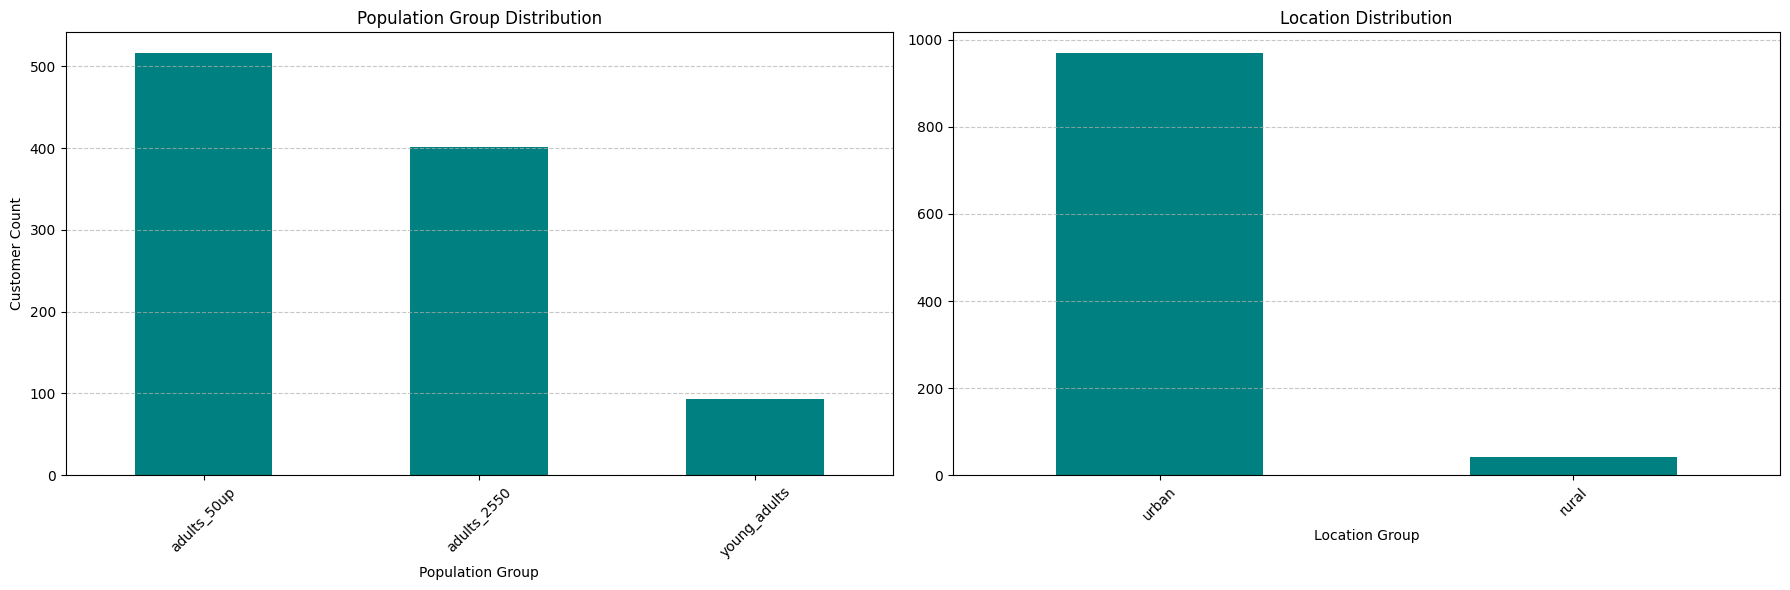

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Population group distribution
customers_df['pop_group'].value_counts().plot(
    kind='bar',
    color=plots_color,
    ax=axes[0]
)
axes[0].set_title('Population Group Distribution')
axes[0].set_xlabel('Population Group')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Location distribution
customers_df['location'].value_counts().plot(
    kind='bar',
    color=plots_color,
    ax=axes[1]
)
axes[1].set_title('Location Distribution')
axes[1].set_xlabel('Location Group')
#axes[1].set_ylabel('Customer Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()